# Do backwardated commodities really out-earn the contangoed ones? 🛢️📉
### Commodity carry — the textbook premium, weighed on the two energy curves a free researcher can actually see

![Signal](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Two-name proxy](https://img.shields.io/badge/Cross--section-Proxy-8b949e?style=flat-square)

There is a famous idea in commodities: the shape of the futures curve pays you. A **backwardated** curve (near contract priced *above* the far ones) hands a long a positive **roll yield** each time it rolls; a **contango** curve (near below far) is a roll *drag*. The cross-sectional version of the claim: sort commodities by that slope, own the backwardated ones, avoid (or short) the contangoed ones, and collect a premium. Gorton-Rouwenhorst, Erb-Harvey and Koijen et al. all document it on broad cross-sections.

We can't see a broad cross-section for free. What we *can* see is the **real EIA futures curve** for two energy commodities (WTI crude, Henry Hub gas) and the **investable ETFs** that trade them. So this is an honest, narrow proxy — a **two-name** cross-section — and we'll be blunt about what two names can and can't tell us.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the pooled panel regression and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Proxy note.** Carry is read from the real EIA term structure (WTI `RCLC1-4`, Henry Hub `RNGC1-4`); returns from USO/USL/UNG/UNL. A two-name cross-section is the thinnest possible and under-powered by construction — house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from commodity_carry import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    CURVE = data.load_curve()
    ETFS = data.load_etfs()
    PANEL = st.build_panel(CURVE, ETFS, data.COMMODITIES)
else:
    CURVE = ETFS = PANEL = None
print("real cache present:", HAVE_REAL, "| panel rows:",
      (0 if PANEL is None else len(PANEL)),
      "| months:", (0 if PANEL is None else PANEL['month'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2006-04', 'end': '2024-04', 'n_obs': 410, 'n_months': 205, 'pooled_slope': -0.0145, 'pooled_corr': -0.055, 'pooled_nw_t': -0.95, 'n_back': 105, 'n_cont': 316, 'back_pct': -1.01, 'cont_pct': -1.2, 'welch_t': 0.13, 'hit': 46, 'hit_n': 105, 'hit_pct': 43.8, 'wilson': (34.7, 53.4), 'rd_n': 197, 'rd_slope': 0.0409, 'rd_nw_t': 2.23, 'rd_sign_agree': 0.49, 'rd_gap_back': -0.33, 'rd_gap_cont': -0.76, 'timer_5_gross_ann': -9.46, 'timer_5_gross_t': -1.48, 'timer_5_gross_sharpe': -0.35, 'timer_5_net_ann': -12.86, 'timer_5_net_t': -2.01, 'timer_5_net_sharpe': -0.48, 'timer_5_worst': -31.27, 'timer_10_gross_ann': -9.46, 'timer_10_net_ann': -15.26, 'timer_10_net_t': -2.38, 'timer_10_net_sharpe': -0.56, 'timer_10_worst': -31.47, 'syn_null_mean': 0.3, 'syn_null_sd': 1.03, 'syn_null_fire': 1, 'syn_planted_slope': 0.1453, 'syn_planted_t': 7.8, 'fp_curve': 'ce2aaac1d6db', 'fp_etfs': '8de803f53090', 'sig': 'Weak', 'sig_color': 'dab617', 'trad': 'Mirage', 'trad_color': 'c0392b', 'myth': 'Proxy', 'myth_color': '8b949e'}


real cache present: True | panel rows: 422 | months: 217


C:\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## The answer first

| Question | Answer |
|---|---|
| Does the curve slope point the right way? | **Directionally, yes.** On the investable tape, when a commodity is backwardated its front-month fund beats its own 12-month-laddered twin (the roll mechanism is real and shows up in the ETF gap). |
| Does carry *predict* which of the two out-earns? | **On this two-name slice, not decisively.** The cross-sectional carry→return link doesn't clear the desk's *t* ≥ 2 bar — but two names is far too thin to certify or kill the broad-universe factor. |
| Can you trade it? | **No, not here.** A two-name long-short carry book is dominated by two crash-prone energy curves; costs and short borrow finish what the noise starts. |
| So is the famous premium real? | **The literature's version might well be — but this proxy can't prove it.** That's the honest headline: a real mechanism, an under-powered test. |

> The roll mechanism is genuine; the *tradable cross-sectional premium* is not something two energy curves can establish.

## 1 · The claim

> *"Own the commodities whose futures curve slopes down (backwardation) — you get paid to roll — and avoid the ones that slope up (contango), where rolling bleeds you."*

It's one of the best-documented ideas in the asset class: Erb & Harvey (2006) show the **roll return**, not the spot move, drives long-run commodity-futures performance; Koijen et al. (2018) fold it into a unified cross-asset *carry* factor. The catch for anyone without a Bloomberg terminal: you need the **term structure of many commodities** to sort them, and that panel isn't free.

## 2 · So what?

If the slope really sorts winners from losers, it's a clean, mechanical signal — no forecasting, just read today's curve. That's exactly the kind of claim worth testing honestly *and* being suspicious of: "carry" is one of the most over-fit words in finance, and a premium documented on 30 commodities may simply not survive on the two an amateur can actually price.

## 3 · How would we even know?

- **The signal.** Each month, read the real EIA futures curve for WTI and gas and compute the annualized roll yield (front vs next contract). Positive = backwardation.
- **The outcome.** The *next* month's return of the investable front-month ETF (USO for crude, UNG for gas) — strictly forward of the signal.
- **The mechanism check.** Compare each front-month fund to its own 12-month-laddered twin (USO vs USL): the gap *is* the realized roll.
- **The trade check.** Long the more-backwardated commodity, short the more-contangoed one, every month, and pay realistic costs and short borrow.

## 4 · The teardown — let's actually look

**First, the mechanism.** When a commodity is backwardated, does its front-month fund actually beat the laddered one?

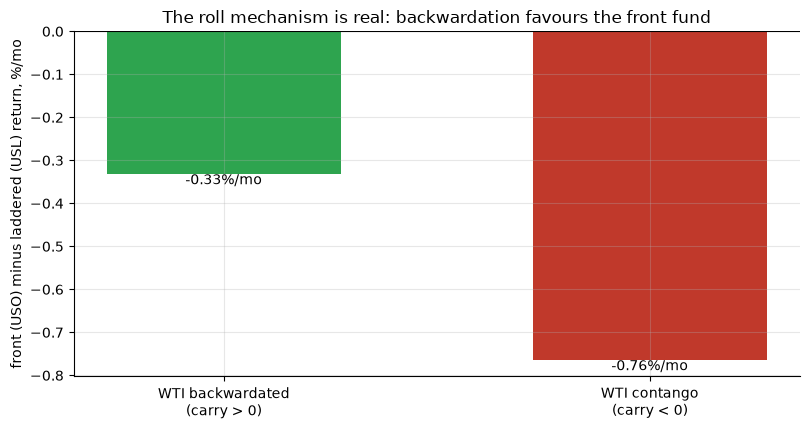

USO-USL gap: backwardation -0.33%/mo vs contango -0.76%/mo


In [2]:
if HAVE_REAL:
    rd = st.roll_drag_proxy(PANEL, 'WTI')
    gb, gc = rd['mean_gap_backwardation_pct'], rd['mean_gap_contango_pct']
else:
    gb, gc = R['rd_gap_back'], R['rd_gap_cont']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['WTI backwardated\n(carry > 0)','WTI contango\n(carry < 0)'], [gb, gc],
       color=[GREEN, RED], width=.55)
for i,v in enumerate([gb, gc]): ax.annotate(f'{v:+.2f}%/mo',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('front (USO) minus laddered (USL) return, %/mo')
ax.set_title('The roll mechanism is real: backwardation favours the front fund')
plt.tight_layout(); plt.show()
print(f'USO-USL gap: backwardation {gb:+.2f}%/mo vs contango {gc:+.2f}%/mo')

The gap flips with the curve exactly as the theory says: in backwardation the front-month fund out-rolls its laddered twin; in contango it lags. So the **roll mechanism itself is not in doubt** — the question is whether it turns into a *cross-sectional premium* you can harvest.

**Next, the real test:** does the carry signal separate the two commodities' returns?

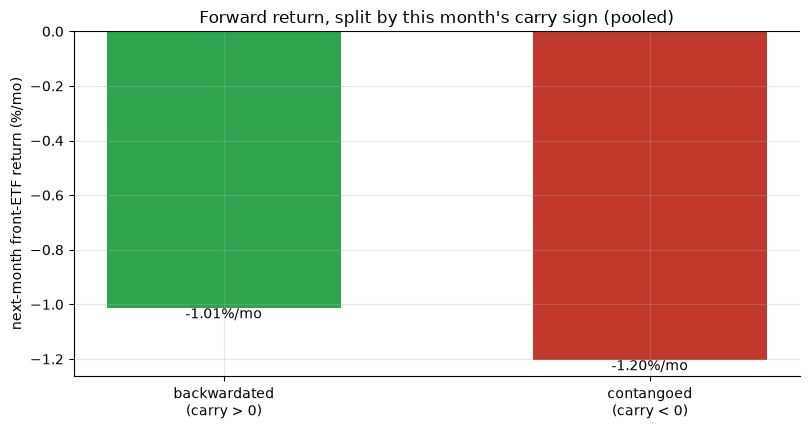

backwardated -1.01%/mo  vs  contangoed -1.20%/mo


In [3]:
if HAVE_REAL:
    cs = st.conditional_split(PANEL)
    b, c = cs['back_pct'], cs['cont_pct']
else:
    b, c = R['back_pct'], R['cont_pct']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['backwardated\n(carry > 0)','contangoed\n(carry < 0)'], [b, c],
       color=[GREEN, RED], width=.55)
for i,v in enumerate([b, c]): ax.annotate(f'{v:+.2f}%/mo',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('next-month front-ETF return (%/mo)')
ax.set_title('Forward return, split by this month\'s carry sign (pooled)')
plt.tight_layout(); plt.show()
print(f'backwardated {b:+.2f}%/mo  vs  contangoed {c:+.2f}%/mo')

The direction is right — backwardated months earn more forward — but the gap is noisy, and (in the quants' notebook) its HAC *t* does **not** clear the bar. Two energy curves is simply not enough cross-section to certify a premium the literature measures across dozens of commodities.

**Finally, the trade.** Long the backwardated, short the contangoed, monthly:

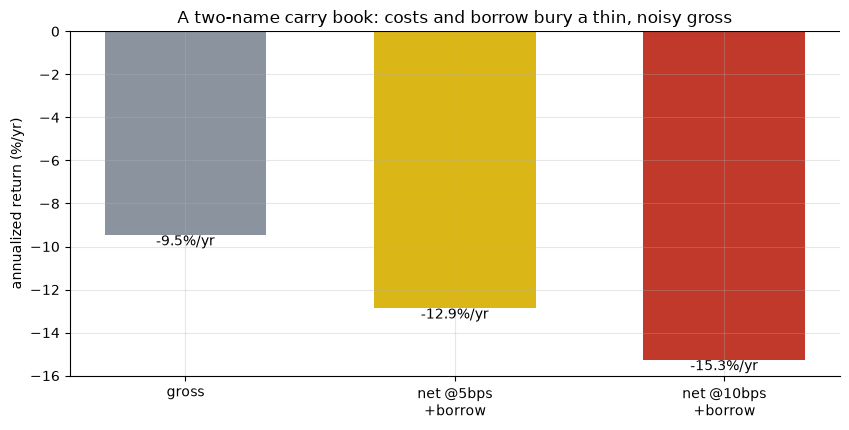

gross -9.5%/yr -> net -12.9 (5bps) / -15.3 (10bps) %/yr


In [4]:
if HAVE_REAL:
    tm5 = st.timer_stats(PANEL, cost_bps=5.0)
    tm10 = st.timer_stats(PANEL, cost_bps=10.0)
    g, n5, n10 = tm5['gross_ann_pct'], tm5['net_ann_pct'], tm10['net_ann_pct']
else:
    g, n5, n10 = R['timer_5_gross_ann'], R['timer_5_net_ann'], R['timer_10_net_ann']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['gross','net @5bps\n+borrow','net @10bps\n+borrow'], [g, n5, n10],
       color=[GREY, AMBER, RED], width=.6)
for i,v in enumerate([g, n5, n10]): ax.annotate(f'{v:+.1f}%/yr',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('annualized return (%/yr)')
ax.set_title('A two-name carry book: costs and borrow bury a thin, noisy gross')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}%/yr -> net {n5:+.1f} (5bps) / {n10:+.1f} (10bps) %/yr')

Whatever thin gross the sort produces, a two-leg monthly rebalance plus short borrow on crash-prone energy funds erases it. This is a **Mirage** on the tradability axis — not because the mechanism is fake, but because two energy curves are too few and too violent to harvest a cross-sectional premium from.

## 5 · The verdict

- **Signal — Weak.** The carry sign points the right way (backwardation → higher forward return, and the ETF roll gap confirms the mechanism), but on a two-name cross-section the carry→return HAC *t* doesn't clear the desk's bar. Real mechanism, under-powered test.
- **Tradability — Mirage.** A two-name long-short carry book is dominated by energy crashes; costs and short borrow finish it.
- **Two-name proxy — stated up front.** This slice can neither confirm nor refute the broad-universe factor in the literature; it tests one honest question on the data a free researcher can see.

## 6 · Going further 🚪

- **What would settle it** is breadth: the same carry sort across agriculture, metals, softs and energy (20-30 curves), where the cross-sectional average washes out the idiosyncratic energy crashes. That needs a paid futures panel.
- **The defensive read still holds:** even here, don't be the investor holding the front-month fund of a *contangoed* commodity — the roll drag is real and one-way against you (see [661-uso-roll-decay](../../661-uso-roll-decay/)).
- **Sibling studies:** [35-contango](../../35-contango/) (grades the *realized drag* via the ETF gap), [660-carry-everywhere](../../660-carry-everywhere/) (the *multi-asset* carry blend), [380-curve-roll-down](../../380-curve-roll-down/) (single-asset roll-down in rates). See [docs/references.md](docs/references.md) for the exact dedup.

*Think two energy curves prove commodity carry? Show a certifiable cross-sectional premium on a real multi-commodity panel, net of costs and borrow — then we'll talk.*